In [6]:
import pandas as pd
import numpy as np
import time
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [7]:
df = pd.read_csv(r"C:\AMRITA\Final_Year_Project_zero_day_27\model_selection_zeroday_fyp_27\UNSW_NB15_training-set.csv")

print(df.shape)

df.head()

(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [8]:
selected_features = [

    "dur",

    "proto",

    "service",

    "spkts",

    "dpkts",

    "sbytes",

    "dbytes",

    "rate",

    "sttl",

    "dttl",

    "sload",

    "dload",

    "sinpkt",

    "dinpkt",

    "sjit",

    "djit",

    "tcprtt",

    "synack",

    "ackdat",

    "ct_srv_src",

    "ct_state_ttl",

    "ct_dst_ltm",

    "ct_src_ltm",

    "ct_srv_dst"

]

df = df[selected_features]

df.head()

,dur,proto,service,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,...,sjit,djit,tcprtt,synack,ackdat,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_ltm,ct_srv_dst
0,0.000011,udp,-,2,0,496,0,90909.0902,254,0,...,0.0,0.0,0.0,0.0,0.0,2,2,1,1,2
1,0.000008,udp,-,2,0,1762,0,125000.0003,254,0,...,0.0,0.0,0.0,0.0,0.0,2,2,1,1,2
2,0.000005,udp,-,2,0,1068,0,200000.0051,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,1,1,3
3,0.000006,udp,-,2,0,900,0,166666.6608,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,2,2,3
4,0.000010,udp,-,2,0,2126,0,100000.0025,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,2,2,3


In [9]:
# Encode categorical columns

for col in ["proto","service"]:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

# Replace infinities

df.replace([np.inf,-np.inf],np.nan,inplace=True)

# Fill missing values

df.fillna(df.median(numeric_only=True),inplace=True)

# Standardize

scaler = StandardScaler()

X = scaler.fit_transform(df)

print(X.shape)

(82332, 24)


In [10]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Any NaN:", np.isnan(X).any())
print("Any infinity:", np.isinf(X).any())

Number of samples: 82332
Number of features: 24
Any NaN: False
Any infinity: False


In [11]:
TUNING_SIZE = min(20000, len(X))

rng = np.random.RandomState(42)

tuning_idx = rng.choice(
    len(X),
    size=TUNING_SIZE,
    replace=False
)

X_tune = X[tuning_idx]

print("Full dataset:", X.shape)
print("Tuning dataset:", X_tune.shape)

Full dataset: (82332, 24)
Tuning dataset: (20000, 24)


In [12]:
def evaluate_clustering(
    X_data,
    labels,
    metric_sample_size=10000
):
    
    labels = np.asarray(labels)
    
    unique_labels = np.unique(labels)
    
    # Remove DBSCAN/OPTICS noise if present
    valid = labels != -1
    
    X_eval = X_data[valid]
    y_eval = labels[valid]
    
    n_clusters = len(
        np.unique(y_eval)
    )
    
    if n_clusters < 2:
        return {
            "Clusters": n_clusters,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan
        }
    
    # Sample only for metric calculation
    if len(X_eval) > metric_sample_size:
        
        rng = np.random.RandomState(42)
        
        idx = rng.choice(
            len(X_eval),
            size=metric_sample_size,
            replace=False
        )
        
        X_eval = X_eval[idx]
        y_eval = y_eval[idx]
    
    silhouette = silhouette_score(
        X_eval,
        y_eval
    )
    
    db = davies_bouldin_score(
        X_eval,
        y_eval
    )
    
    ch = calinski_harabasz_score(
        X_eval,
        y_eval
    )
    
    return {
        "Clusters": n_clusters,
        "Silhouette": silhouette,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    }

In [13]:
def build_autoencoder(
    input_dim,
    latent_dim
):
    
    # Input
    inputs = Input(
        shape=(input_dim,)
    )
    
    # Encoder
    x = Dense(
        16,
        activation="relu"
    )(inputs)
    
    x = Dense(
        8,
        activation="relu"
    )(x)
    
    latent = Dense(
        latent_dim,
        activation="linear",
        name="latent"
    )(x)
    
    # Decoder
    x = Dense(
        8,
        activation="relu"
    )(latent)
    
    x = Dense(
        16,
        activation="relu"
    )(x)
    
    outputs = Dense(
        input_dim,
        activation="linear"
    )(x)
    
    # Autoencoder
    autoencoder = Model(
        inputs,
        outputs
    )
    
    # Encoder only
    encoder = Model(
        inputs,
        latent
    )
    
    return autoencoder, encoder

In [14]:
def train_autoencoder(
    X_data,
    latent_dim,
    epochs=30,
    batch_size=256
):
    
    input_dim = X_data.shape[1]
    
    autoencoder, encoder = build_autoencoder(
        input_dim=input_dim,
        latent_dim=latent_dim
    )
    
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )
    
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
    
    history = autoencoder.fit(
        X_data,
        X_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0
    )
    
    latent_data = encoder.predict(
        X_data,
        batch_size=batch_size,
        verbose=0
    )
    
    return (
        autoencoder,
        encoder,
        latent_data,
        history
    )

In [15]:
latent_dim = 4

start_time = time.time()

autoencoder, encoder, X_latent, history = train_autoencoder(
    X_tune,
    latent_dim=latent_dim,
    epochs=30,
    batch_size=256
)

ae_time = time.time() - start_time

print(
    "Autoencoder training time:",
    round(ae_time, 2),
    "seconds"
)

print(
    "Original shape:",
    X_tune.shape
)

print(
    "Latent shape:",
    X_latent.shape
)

Autoencoder training time: 20.87 seconds
Original shape: (20000, 24)
Latent shape: (20000, 4)


In [16]:
k = 10

start_time = time.time()

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(
    X_latent
)

kmeans_time = time.time() - start_time

metrics = evaluate_clustering(
    X_latent,
    labels
)

print("K =", k)

print(
    "Silhouette:",
    round(metrics["Silhouette"], 4)
)

print(
    "Davies-Bouldin:",
    round(metrics["Davies-Bouldin"], 4)
)

print(
    "Calinski-Harabasz:",
    round(metrics["Calinski-Harabasz"], 4)
)

print(
    "Total time:",
    round(
        ae_time + kmeans_time,
        2
    ),
    "seconds"
)

K = 10
Silhouette: 0.4872
Davies-Bouldin: 0.78
Calinski-Harabasz: 6139.862
Total time: 21.5 seconds


In [17]:
latent_dimensions = [
    2,
    4,
    8
]

k_values = range(
    2,
    16
)

ae_results = []

for latent_dim in latent_dimensions:
    
    print("\n" + "=" * 60)
    print(
        "Training Autoencoder "
        "with latent_dim =",
        latent_dim
    )
    print("=" * 60)
    
    # -----------------------------------------
    # Train autoencoder ONCE for this
    # latent dimension
    # -----------------------------------------
    
    ae_start = time.time()
    
    (
        autoencoder,
        encoder,
        X_latent,
        history
    ) = train_autoencoder(
        X_tune,
        latent_dim=latent_dim,
        epochs=30,
        batch_size=256
    )
    
    ae_training_time = (
        time.time() - ae_start
    )
    
    print(
        "Autoencoder time:",
        round(ae_training_time, 2),
        "seconds"
    )
    
    # -----------------------------------------
    # Try different K values
    # -----------------------------------------
    
    for k in k_values:
        
        kmeans_start = time.time()
        
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        
        labels = kmeans.fit_predict(
            X_latent
        )
        
        kmeans_time = (
            time.time()
            - kmeans_start
        )
        
        metrics = evaluate_clustering(
            X_latent,
            labels
        )
        
        total_time = (
            ae_training_time
            + kmeans_time
        )
        
        result = {
            "Model":
                "Autoencoder + K-Means",
            
            "Latent Dimension":
                latent_dim,
            
            "K":
                k,
            
            "Silhouette":
                metrics["Silhouette"],
            
            "Davies-Bouldin":
                metrics["Davies-Bouldin"],
            
            "Calinski-Harabasz":
                metrics["Calinski-Harabasz"],
            
            "Training Time (s)":
                total_time
        }
        
        ae_results.append(
            result
        )
        
        print(
            f"latent={latent_dim}, "
            f"K={k}, "
            f"Silhouette="
            f"{metrics['Silhouette']:.4f}"
        )


Training Autoencoder with latent_dim = 2
Autoencoder time: 19.8 seconds
latent=2, K=2, Silhouette=0.8695
latent=2, K=3, Silhouette=0.4081
latent=2, K=4, Silhouette=0.4487
latent=2, K=5, Silhouette=0.4992
latent=2, K=6, Silhouette=0.4344
latent=2, K=7, Silhouette=0.4383
latent=2, K=8, Silhouette=0.4544
latent=2, K=9, Silhouette=0.4542
latent=2, K=10, Silhouette=0.4712
latent=2, K=11, Silhouette=0.4808
latent=2, K=12, Silhouette=0.4846
latent=2, K=13, Silhouette=0.4949
latent=2, K=14, Silhouette=0.4961
latent=2, K=15, Silhouette=0.4984

Training Autoencoder with latent_dim = 4
Autoencoder time: 19.96 seconds
latent=4, K=2, Silhouette=0.5838
latent=4, K=3, Silhouette=0.5758
latent=4, K=4, Silhouette=0.5709
latent=4, K=5, Silhouette=0.3843
latent=4, K=6, Silhouette=0.3999
latent=4, K=7, Silhouette=0.4244
latent=4, K=8, Silhouette=0.4243
latent=4, K=9, Silhouette=0.4303
latent=4, K=10, Silhouette=0.4352
latent=4, K=11, Silhouette=0.4432
latent=4, K=12, Silhouette=0.4144
latent=4, K=13, Sil

In [18]:
ae_tuning_results = pd.DataFrame(
    ae_results
)

ae_tuning_results = ae_tuning_results.sort_values(
    by="Silhouette",
    ascending=False
).reset_index(drop=True)

display(
    ae_tuning_results.round(4)
)

,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
0,Autoencoder + K-Means,2,2,0.8695,0.7719,2670.6476,19.9586
1,Autoencoder + K-Means,4,2,0.5838,0.8588,5168.9701,20.1245
2,Autoencoder + K-Means,4,3,0.5758,0.7029,5864.6973,20.2556
3,Autoencoder + K-Means,4,4,0.5709,0.7238,5308.1492,20.2150
4,Autoencoder + K-Means,8,8,0.5179,0.7475,6881.6754,20.9108
5,Autoencoder + K-Means,8,3,0.5085,0.7609,6088.7860,20.6926
6,Autoencoder + K-Means,8,7,0.5050,0.7066,6652.6327,20.9075
7,Autoencoder + K-Means,8,6,0.5029,0.8217,6771.7240,20.9630
8,Autoencoder + K-Means,8,5,0.5016,0.8531,6559.9842,20.8036
9,Autoencoder + K-Means,2,5,0.4992,0.6993,4866.3416,20.0052


In [19]:
best_ae = ae_tuning_results.iloc[0]

print("=" * 50)
print("BEST AUTOENCODER + K-MEANS CONFIGURATION")
print("=" * 50)

print(
    "Latent Dimension:",
    int(best_ae["Latent Dimension"])
)

print(
    "K:",
    int(best_ae["K"])
)

print(
    "Silhouette:",
    round(
        best_ae["Silhouette"],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        best_ae["Davies-Bouldin"],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        best_ae["Calinski-Harabasz"],
        4
    )
)

print(
    "Training Time:",
    round(
        best_ae["Training Time (s)"],
        2
    ),
    "seconds"
)

BEST AUTOENCODER + K-MEANS CONFIGURATION
Latent Dimension: 2
K: 2
Silhouette: 0.8695
Davies-Bouldin: 0.7719
Calinski-Harabasz: 2670.6476
Training Time: 19.96 seconds


In [20]:
print("BEST SILHOUETTE")
display(
    ae_tuning_results
    .sort_values(
        "Silhouette",
        ascending=False
    )
    .head(5)
    .round(4)
)

BEST SILHOUETTE


,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
0,Autoencoder + K-Means,2,2,0.8695,0.7719,2670.6476,19.9586
1,Autoencoder + K-Means,4,2,0.5838,0.8588,5168.9701,20.1245
2,Autoencoder + K-Means,4,3,0.5758,0.7029,5864.6973,20.2556
3,Autoencoder + K-Means,4,4,0.5709,0.7238,5308.1492,20.2150
4,Autoencoder + K-Means,8,8,0.5179,0.7475,6881.6754,20.9108


In [21]:
print("BEST DAVIES-BOULDIN")
display(
    ae_tuning_results
    .sort_values(
        "Davies-Bouldin",
        ascending=True
    )
    .head(5)
    .round(4)
)

BEST DAVIES-BOULDIN


,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
10,Autoencoder + K-Means,2,15,0.4984,0.5810,6016.8809,20.8991
11,Autoencoder + K-Means,2,14,0.4961,0.6239,6326.3703,20.9716
12,Autoencoder + K-Means,2,13,0.4949,0.6340,5887.4449,20.2931
15,Autoencoder + K-Means,2,12,0.4846,0.6479,5848.4447,20.2937
22,Autoencoder + K-Means,2,10,0.4712,0.6620,5481.7258,20.2062


In [22]:
print("BEST CALINSKI-HARABASZ")
display(
    ae_tuning_results
    .sort_values(
        "Calinski-Harabasz",
        ascending=False
    )
    .head(5)
    .round(4)
)

BEST CALINSKI-HARABASZ


,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
13,Autoencoder + K-Means,8,4,0.4917,0.7143,6928.1833,20.7435
4,Autoencoder + K-Means,8,8,0.5179,0.7475,6881.6754,20.9108
20,Autoencoder + K-Means,8,10,0.4761,0.8333,6848.9004,20.9924
16,Autoencoder + K-Means,8,11,0.4809,0.7926,6840.8753,21.0755
19,Autoencoder + K-Means,8,12,0.4776,0.8466,6799.0078,21.0810


In [23]:
ae_tuning_results.to_csv(
    "autoencoder_kmeans_tuning_results.csv",
    index=False
)

print(
    "Saved as "
    "autoencoder_kmeans_tuning_results.csv"
)

Saved as autoencoder_kmeans_tuning_results.csv


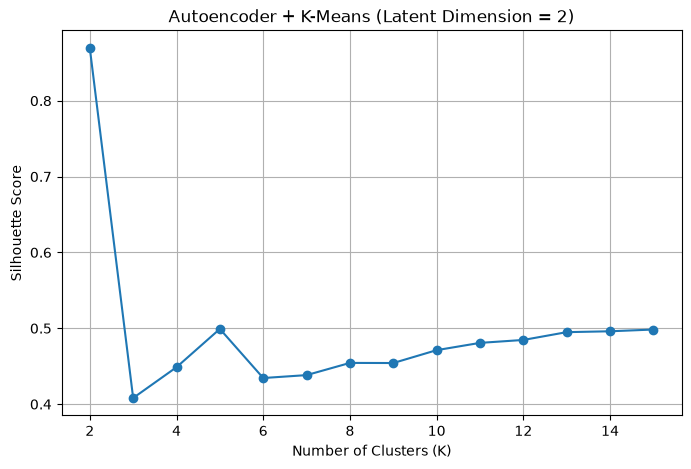

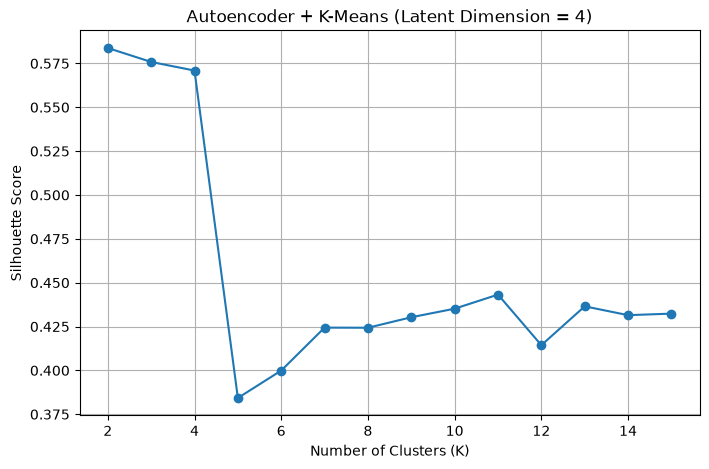

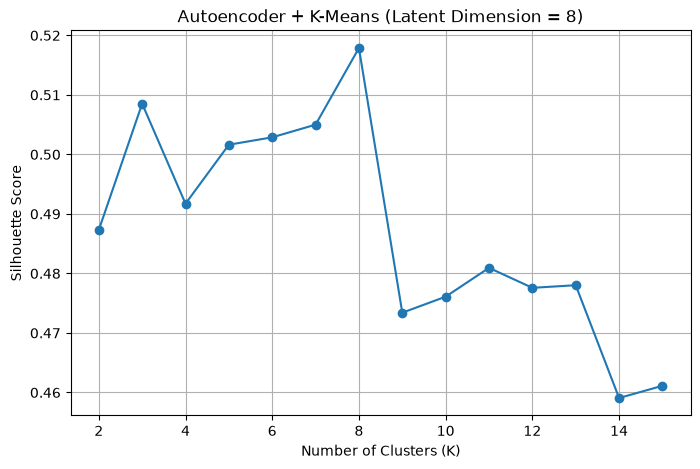

In [24]:
import matplotlib.pyplot as plt

for latent_dim in latent_dimensions:
    
    subset = ae_tuning_results[
        ae_tuning_results[
            "Latent Dimension"
        ] == latent_dim
    ].sort_values("K")
    
    plt.figure(
        figsize=(8, 5)
    )
    
    plt.plot(
        subset["K"],
        subset["Silhouette"],
        marker="o"
    )
    
    plt.xlabel(
        "Number of Clusters (K)"
    )
    
    plt.ylabel(
        "Silhouette Score"
    )
    
    plt.title(
        f"Autoencoder + K-Means "
        f"(Latent Dimension = {latent_dim})"
    )
    
    plt.grid(True)
    
    plt.show()

In [25]:
best_latent_dim = int(
    best_ae["Latent Dimension"]
)

best_k = int(
    best_ae["K"]
)

print(
    "Best latent dimension:",
    best_latent_dim
)

print(
    "Best K:",
    best_k
)

Best latent dimension: 2
Best K: 2


In [26]:
print(
    "Training final "
    "Autoencoder + K-Means..."
)

final_start = time.time()

(
    final_autoencoder,
    final_encoder,
    X_final_latent,
    final_history
) = train_autoencoder(
    X,
    latent_dim=best_latent_dim,
    epochs=30,
    batch_size=256
)

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(
    X_final_latent
)

final_time = (
    time.time() - final_start
)

print(
    "Final training time:",
    round(
        final_time,
        2
    ),
    "seconds"
)

Training final Autoencoder + K-Means...
Final training time: 44.71 seconds


In [27]:
final_metrics = evaluate_clustering(
    X_final_latent,
    final_labels,
    metric_sample_size=10000
)

print("=" * 50)
print("FINAL AUTOENCODER + K-MEANS")
print("=" * 50)

print(
    "Latent Dimension:",
    best_latent_dim
)

print(
    "K:",
    best_k
)

print(
    "Silhouette:",
    round(
        final_metrics["Silhouette"],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        final_metrics["Davies-Bouldin"],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        final_metrics["Calinski-Harabasz"],
        4
    )
)

print(
    "Training Time:",
    round(
        final_time,
        2
    ),
    "seconds"
)

FINAL AUTOENCODER + K-MEANS
Latent Dimension: 2
K: 2
Silhouette: 0.5732
Davies-Bouldin: 0.69
Calinski-Harabasz: 5960.0577
Training Time: 44.71 seconds


In [28]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [29]:
print("Full dataset:", X.shape)
print("Tuning dataset:", X_tune.shape)

Full dataset: (82332, 24)
Tuning dataset: (20000, 24)


In [30]:
def evaluate_clustering(
    X_data,
    labels,
    metric_sample_size=10000
):
    
    labels = np.asarray(labels)
    
    # Remove noise labels if any
    valid = labels != -1
    
    X_eval = X_data[valid]
    y_eval = labels[valid]
    
    n_clusters = len(
        np.unique(y_eval)
    )
    
    if n_clusters < 2:
        return {
            "Clusters": n_clusters,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan
        }
    
    # Fixed sampling for faster metric calculation
    if len(X_eval) > metric_sample_size:
        
        rng = np.random.RandomState(42)
        
        idx = rng.choice(
            len(X_eval),
            size=metric_sample_size,
            replace=False
        )
        
        X_eval = X_eval[idx]
        y_eval = y_eval[idx]
    
    return {
        "Clusters": n_clusters,
        
        "Silhouette": silhouette_score(
            X_eval,
            y_eval
        ),
        
        "Davies-Bouldin": davies_bouldin_score(
            X_eval,
            y_eval
        ),
        
        "Calinski-Harabasz": calinski_harabasz_score(
            X_eval,
            y_eval
        )
    }

In [31]:
def build_dec_autoencoder(
    input_dim,
    latent_dim
):
    
    inputs = Input(
        shape=(input_dim,)
    )
    
    # Encoder
    x = Dense(
        32,
        activation="relu"
    )(inputs)
    
    x = Dense(
        16,
        activation="relu"
    )(x)
    
    latent = Dense(
        latent_dim,
        activation="linear",
        name="latent"
    )(x)
    
    # Decoder
    x = Dense(
        16,
        activation="relu"
    )(latent)
    
    x = Dense(
        32,
        activation="relu"
    )(x)
    
    outputs = Dense(
        input_dim,
        activation="linear"
    )(x)
    
    autoencoder = Model(
        inputs,
        outputs,
        name="DEC_Autoencoder"
    )
    
    encoder = Model(
        inputs,
        latent,
        name="DEC_Encoder"
    )
    
    return autoencoder, encoder

In [32]:
def pretrain_dec_autoencoder(
    X_data,
    latent_dim,
    epochs=20,
    batch_size=256
):
    
    input_dim = X_data.shape[1]
    
    autoencoder, encoder = build_dec_autoencoder(
        input_dim=input_dim,
        latent_dim=latent_dim
    )
    
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )
    
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
    
    history = autoencoder.fit(
        X_data,
        X_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0
    )
    
    return (
        autoencoder,
        encoder,
        history
    )

In [33]:
class DECLayer(tf.keras.layers.Layer):
    
    def __init__(
        self,
        n_clusters,
        alpha=1.0,
        **kwargs
    ):
        
        super().__init__(**kwargs)
        
        self.n_clusters = n_clusters
        self.alpha = alpha
    
    def build(self, input_shape):
        
        input_dim = int(
            input_shape[-1]
        )
        
        self.clusters = self.add_weight(
            shape=(
                self.n_clusters,
                input_dim
            ),
            initializer="glorot_uniform",
            trainable=True,
            name="cluster_centers"
        )
        
        super().build(input_shape)
    
    def call(self, inputs):
        
        # Squared distance from every
        # sample to every cluster center
        
        distances = tf.reduce_sum(
            tf.square(
                tf.expand_dims(
                    inputs,
                    axis=1
                )
                - self.clusters
            ),
            axis=2
        )
        
        # Student's t-distribution
        
        q = 1.0 / (
            1.0 + distances / self.alpha
        )
        
        q = tf.pow(
            q,
            (self.alpha + 1.0) / 2.0
        )
        
        q = q / tf.reduce_sum(
            q,
            axis=1,
            keepdims=True
        )
        
        return q

In [34]:
def dec_target_distribution(q):
    
    weight = (
        q ** 2
    ) / (
        np.sum(q, axis=0) + 1e-10
    )
    
    target = (
        weight.T
        /
        (
            np.sum(
                weight,
                axis=1
            ) + 1e-10
        )
    ).T
    
    return target

In [35]:
def train_dec(
    X_data,
    latent_dim=4,
    n_clusters=10,
    pretrain_epochs=20,
    dec_iterations=500,
    update_interval=50,
    batch_size=256,
    learning_rate=0.001,
    tol=0.001,
    random_state=42
):
    
    start_time = time.time()
    
    # ==================================================
    # STEP 1 — Pretrain Autoencoder
    # ==================================================
    
    (
        autoencoder,
        encoder,
        history
    ) = pretrain_dec_autoencoder(
        X_data,
        latent_dim=latent_dim,
        epochs=pretrain_epochs,
        batch_size=batch_size
    )
    
    # ==================================================
    # STEP 2 — Obtain latent representation
    # ==================================================
    
    latent_data = encoder.predict(
        X_data,
        batch_size=batch_size,
        verbose=0
    )
    
    # ==================================================
    # STEP 3 — Initialize cluster centers using K-Means
    # ==================================================
    
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    
    initial_labels = kmeans.fit_predict(
        latent_data
    )
    
    initial_centers = (
        kmeans.cluster_centers_
    )
    
    # ==================================================
    # STEP 4 — Create DEC clustering layer
    # ==================================================
    
    clustering_layer = DECLayer(
        n_clusters=n_clusters,
        alpha=1.0,
        name="clustering"
    )
    
    # Build the layer
    _ = clustering_layer(
        encoder.output
    )
    
    # Initialize cluster centers
    clustering_layer.set_weights(
        [initial_centers]
    )
    
    # ==================================================
    # STEP 5 — Build DEC model
    # ==================================================
    
    dec_model = Model(
        inputs=encoder.input,
        outputs=clustering_layer(
            encoder.output
        )
    )
    
    dec_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="kld"
    )
    
    # ==================================================
    # STEP 6 — Initial probability distribution
    # ==================================================
    
    q = dec_model.predict(
        X_data,
        batch_size=batch_size,
        verbose=0
    )
    
    p = dec_target_distribution(q)
    
    previous_labels = q.argmax(
        axis=1
    )
    
    # ==================================================
    # STEP 7 — DEC optimization
    # ==================================================
    
    final_iteration = 0
    
    for iteration in range(
        dec_iterations
    ):
        
        final_iteration = iteration
        
        # ----------------------------------------------
        # Update target distribution
        # ----------------------------------------------
        
        if iteration % update_interval == 0:
            
            q = dec_model.predict(
                X_data,
                batch_size=batch_size,
                verbose=0
            )
            
            p = dec_target_distribution(q)
            
            current_labels = q.argmax(
                axis=1
            )
            
            # Check convergence
            if iteration > 0:
                
                delta_label = np.mean(
                    current_labels
                    != previous_labels
                )
                
                if delta_label < tol:
                    
                    print(
                        f"Converged at "
                        f"iteration {iteration}"
                    )
                    
                    break
            
            previous_labels = current_labels
        
        # ----------------------------------------------
        # Mini-batch training
        # ----------------------------------------------
        
        batch_start = (
            iteration * batch_size
        ) % len(X_data)
        
        batch_end = min(
            batch_start + batch_size,
            len(X_data)
        )
        
        batch_indices = np.arange(
            batch_start,
            batch_end
        )
        
        dec_model.train_on_batch(
            X_data[batch_indices],
            p[batch_indices]
        )
    
    # ==================================================
    # STEP 8 — Final prediction
    # ==================================================
    
    q_final = dec_model.predict(
        X_data,
        batch_size=batch_size,
        verbose=0
    )
    
    final_labels = q_final.argmax(
        axis=1
    )
    
    final_latent = encoder.predict(
        X_data,
        batch_size=batch_size,
        verbose=0
    )
    
    training_time = (
        time.time()
        - start_time
    )
    
    return {
        "model": dec_model,
        "encoder": encoder,
        "latent": final_latent,
        "labels": final_labels,
        "training_time": training_time,
        "iterations": final_iteration + 1
    }

In [36]:
dec_test_start = time.time()

dec_test = train_dec(
    X_tune,
    latent_dim=4,
    n_clusters=10,
    pretrain_epochs=20,
    dec_iterations=500,
    update_interval=50,
    batch_size=256,
    learning_rate=0.001,
    random_state=42
)

print(
    "Total training time:",
    round(
        dec_test["training_time"],
        2
    ),
    "seconds"
)

print(
    "Iterations:",
    dec_test["iterations"]
)

print(
    "Number of clusters:",
    len(
        np.unique(
            dec_test["labels"]
        )
    )
)


Total training time: 28.79 seconds
Iterations: 500
Number of clusters: 10


In [37]:
dec_test_metrics = evaluate_clustering(
    dec_test["latent"],
    dec_test["labels"],
    metric_sample_size=10000
)

print("=" * 50)
print("DEC TEST RESULT")
print("=" * 50)

print(
    "Silhouette:",
    round(
        dec_test_metrics["Silhouette"],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        dec_test_metrics["Davies-Bouldin"],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        dec_test_metrics["Calinski-Harabasz"],
        4
    )
)

DEC TEST RESULT
Silhouette: 0.7969
Davies-Bouldin: 0.7171
Calinski-Harabasz: 3039.6403


In [38]:
DEC_CONFIGS = [
    (2, 5),
    (2, 10),
    (4, 5),
    (4, 10),
    (8, 5),
    (8, 10)
]

dec_results = []

for latent_dim, n_clusters in DEC_CONFIGS:
    
    print("\n" + "=" * 60)
    
    print(
        f"DEC configuration: "
        f"latent_dim={latent_dim}, "
        f"K={n_clusters}"
    )
    
    print("=" * 60)
    
    try:
        
        result = train_dec(
            X_tune,
            
            latent_dim=latent_dim,
            
            n_clusters=n_clusters,
            
            pretrain_epochs=20,
            
            dec_iterations=500,
            
            update_interval=50,
            
            batch_size=256,
            
            learning_rate=0.001,
            
            tol=0.001,
            
            random_state=42
        )
        
        metrics = evaluate_clustering(
            result["latent"],
            result["labels"],
            metric_sample_size=10000
        )
        
        result_row = {
            
            "Model":
                "DEC",
            
            "Latent Dimension":
                latent_dim,
            
            "K":
                n_clusters,
            
            "Silhouette":
                metrics["Silhouette"],
            
            "Davies-Bouldin":
                metrics["Davies-Bouldin"],
            
            "Calinski-Harabasz":
                metrics["Calinski-Harabasz"],
            
            "Training Time (s)":
                result["training_time"],
            
            "Iterations":
                result["iterations"]
        }
        
        dec_results.append(
            result_row
        )
        
        print(
            f"Silhouette: "
            f"{metrics['Silhouette']:.4f}"
        )
        
        print(
            f"Davies-Bouldin: "
            f"{metrics['Davies-Bouldin']:.4f}"
        )
        
        print(
            f"Calinski-Harabasz: "
            f"{metrics['Calinski-Harabasz']:.2f}"
        )
        
        print(
            f"Time: "
            f"{result['training_time']:.2f}s"
        )
        
    except Exception as e:
        
        print(
            "ERROR:",
            str(e)
        )


DEC configuration: latent_dim=2, K=5
Converged at iteration 400
Silhouette: 0.9162
Davies-Bouldin: 0.3971
Calinski-Harabasz: 36413.12
Time: 25.05s

DEC configuration: latent_dim=2, K=10
Silhouette: 0.7083
Davies-Bouldin: 0.5206
Calinski-Harabasz: 6860.60
Time: 26.34s

DEC configuration: latent_dim=4, K=5
Silhouette: 0.7851
Davies-Bouldin: 0.4051
Calinski-Harabasz: 4947.87
Time: 24.84s

DEC configuration: latent_dim=4, K=10
Silhouette: 0.7770
Davies-Bouldin: 0.5072
Calinski-Harabasz: 7453.31
Time: 27.38s

DEC configuration: latent_dim=8, K=5
Silhouette: 0.8249
Davies-Bouldin: 0.4709
Calinski-Harabasz: 10741.95
Time: 25.91s

DEC configuration: latent_dim=8, K=10
Silhouette: 0.7387
Davies-Bouldin: 0.4908
Calinski-Harabasz: 6985.92
Time: 27.14s


In [39]:
dec_tuning_results = pd.DataFrame(
    dec_results
)

dec_tuning_results = dec_tuning_results.sort_values(
    by="Silhouette",
    ascending=False
).reset_index(drop=True)

display(
    dec_tuning_results.round(4)
)

,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s),Iterations
0,DEC,2,5,0.9162,0.3971,36413.1180,25.0508,401
1,DEC,8,5,0.8249,0.4709,10741.9497,25.9104,500
2,DEC,4,5,0.7851,0.4051,4947.8715,24.8369,500
3,DEC,4,10,0.7770,0.5072,7453.3082,27.3751,500
4,DEC,8,10,0.7387,0.4908,6985.9211,27.1424,500
5,DEC,2,10,0.7083,0.5206,6860.5971,26.3409,500


In [40]:
best_dec = dec_tuning_results.iloc[0]

print("=" * 50)
print("BEST DEC CONFIGURATION")
print("=" * 50)

print(
    "Latent Dimension:",
    int(best_dec["Latent Dimension"])
)

print(
    "K:",
    int(best_dec["K"])
)

print(
    "Silhouette:",
    round(
        best_dec["Silhouette"],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        best_dec["Davies-Bouldin"],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        best_dec["Calinski-Harabasz"],
        4
    )
)

print(
    "Training Time:",
    round(
        best_dec["Training Time (s)"],
        2
    ),
    "seconds"
)

BEST DEC CONFIGURATION
Latent Dimension: 2
K: 5
Silhouette: 0.9162
Davies-Bouldin: 0.3971
Calinski-Harabasz: 36413.118
Training Time: 25.05 seconds


In [41]:
print("TOP 5 — SILHOUETTE")

display(
    dec_tuning_results
    .sort_values(
        "Silhouette",
        ascending=False
    )
    .head(5)
    .round(4)
)

TOP 5 — SILHOUETTE


,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s),Iterations
0,DEC,2,5,0.9162,0.3971,36413.1180,25.0508,401
1,DEC,8,5,0.8249,0.4709,10741.9497,25.9104,500
2,DEC,4,5,0.7851,0.4051,4947.8715,24.8369,500
3,DEC,4,10,0.7770,0.5072,7453.3082,27.3751,500
4,DEC,8,10,0.7387,0.4908,6985.9211,27.1424,500


In [42]:
print("TOP 5 — DAVIES-BOULDIN")

display(
    dec_tuning_results
    .sort_values(
        "Davies-Bouldin",
        ascending=True
    )
    .head(5)
    .round(4)
)

TOP 5 — DAVIES-BOULDIN


,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s),Iterations
0,DEC,2,5,0.9162,0.3971,36413.1180,25.0508,401
2,DEC,4,5,0.7851,0.4051,4947.8715,24.8369,500
1,DEC,8,5,0.8249,0.4709,10741.9497,25.9104,500
4,DEC,8,10,0.7387,0.4908,6985.9211,27.1424,500
3,DEC,4,10,0.7770,0.5072,7453.3082,27.3751,500


In [43]:
print("TOP 5 — CALINSKI-HARABASZ")

display(
    dec_tuning_results
    .sort_values(
        "Calinski-Harabasz",
        ascending=False
    )
    .head(5)
    .round(4)
)

TOP 5 — CALINSKI-HARABASZ


,Model,Latent Dimension,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s),Iterations
0,DEC,2,5,0.9162,0.3971,36413.1180,25.0508,401
1,DEC,8,5,0.8249,0.4709,10741.9497,25.9104,500
3,DEC,4,10,0.7770,0.5072,7453.3082,27.3751,500
4,DEC,8,10,0.7387,0.4908,6985.9211,27.1424,500
5,DEC,2,10,0.7083,0.5206,6860.5971,26.3409,500


In [44]:
dec_tuning_results.to_csv(
    "DEC_tuning_results.csv",
    index=False
)

print(
    "Saved: DEC_tuning_results.csv"
)

Saved: DEC_tuning_results.csv


In [45]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Lambda
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [46]:
TUNING_SIZE = min(20000, len(X))

rng = np.random.RandomState(42)

tuning_idx = rng.choice(
    len(X),
    size=TUNING_SIZE,
    replace=False
)

X_tune = X[tuning_idx]

print("Full dataset:", X.shape)
print("Tuning dataset:", X_tune.shape)

Full dataset: (82332, 24)
Tuning dataset: (20000, 24)


In [47]:
def evaluate_clustering(
    X_data,
    labels,
    metric_sample_size=10000
):
    
    labels = np.asarray(labels)
    
    valid = labels != -1
    
    X_eval = X_data[valid]
    y_eval = labels[valid]
    
    n_clusters = len(
        np.unique(y_eval)
    )
    
    if n_clusters < 2:
        return {
            "Clusters": n_clusters,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan
        }
    
    if len(X_eval) > metric_sample_size:
        
        rng = np.random.RandomState(42)
        
        idx = rng.choice(
            len(X_eval),
            size=metric_sample_size,
            replace=False
        )
        
        X_eval = X_eval[idx]
        y_eval = y_eval[idx]
    
    return {
        "Clusters": n_clusters,
        
        "Silhouette": silhouette_score(
            X_eval,
            y_eval
        ),
        
        "Davies-Bouldin": davies_bouldin_score(
            X_eval,
            y_eval
        ),
        
        "Calinski-Harabasz": calinski_harabasz_score(
            X_eval,
            y_eval
        )
    }

In [52]:
from keras import ops, random

class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        clipped_log_var = ops.clip(z_log_var, -10.0, 10.0)
        epsilon = random.normal(
            shape=ops.shape(z_mean),
            dtype=z_mean.dtype
        )
        kl_loss = -0.5 * ops.mean(
            ops.sum(
                1 + clipped_log_var
                - ops.square(z_mean)
                - ops.exp(clipped_log_var),
                axis=1
            )
        )
        self.add_loss(0.001 * kl_loss)
        return z_mean + ops.exp(0.5 * clipped_log_var) * epsilon

In [53]:
def build_vae(
    input_dim,
    latent_dim
):
    encoder_inputs = Input(
        shape=(input_dim,),
        name="encoder_input"
    )

    x = Dense(
        32,
        activation="relu"
    )(encoder_inputs)

    x = Dense(
        16,
        activation="relu"
    )(x)

    z_mean = Dense(
        latent_dim,
        name="z_mean"
    )(x)

    z_log_var = Dense(
        latent_dim,
        name="z_log_var"
    )(x)

    z = Sampling()(
        [z_mean, z_log_var]
    )

    encoder = Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="encoder"
    )

    latent_inputs = Input(
        shape=(latent_dim,),
        name="z_sampling"
    )

    x = Dense(
        16,
        activation="relu"
    )(latent_inputs)

    x = Dense(
        32,
        activation="relu"
    )(x)

    decoder_outputs = Dense(
        input_dim,
        activation="linear"
    )(x)

    decoder = Model(
        latent_inputs,
        decoder_outputs,
        name="decoder"
    )

    vae_inputs = Input(
        shape=(input_dim,),
        name="vae_input"
    )

    z_mean, z_log_var, z = encoder(
        vae_inputs
    )

    reconstructed = decoder(z)

    vae = Model(
        vae_inputs,
        reconstructed,
        name="VAE"
    )

    return (
        vae,
        encoder,
        decoder
    )

In [54]:
def train_vae(
    X_data,
    latent_dim,
    epochs=20,
    batch_size=256,
    learning_rate=1e-4
):
    input_dim = X_data.shape[1]

    vae, encoder, decoder = build_vae(
        input_dim=input_dim,
        latent_dim=latent_dim
    )

    vae.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss="mse"
    )

    early_stopping = EarlyStopping(
        monitor="loss",
        patience=3,
        restore_best_weights=True
    )

    history = vae.fit(
        X_data,
        X_data,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    z_mean, z_log_var, z = encoder.predict(
        X_data,
        batch_size=batch_size,
        verbose=0
    )

    if not np.isfinite(z_mean).all():
        raise ValueError(
            "VAE produced non-finite latent values. "
            "Lower the learning rate or rebuild the model."
        )

    return (
        vae,
        encoder,
        decoder,
        z_mean,
        history
    )

In [55]:
test_latent_dim = 4

start_time = time.time()

(
    test_vae,
    test_encoder,
    test_decoder,
    test_latent,
    test_history
) = train_vae(
    X_tune,
    latent_dim=test_latent_dim,
    epochs=20,
    batch_size=256,
    learning_rate=1e-4
)

vae_time = time.time() - start_time

print(
    "VAE training time:",
    round(vae_time, 2),
    "seconds"
)

print(
    "Original shape:",
    X_tune.shape
)

print(
    "Latent shape:",
    test_latent.shape
)

VAE training time: 17.49 seconds
Original shape: (20000, 24)
Latent shape: (20000, 4)


In [58]:
test_components = 5

gmm_start = time.time()

gmm = GaussianMixture(
    n_components=test_components,
    covariance_type="full",
    reg_covar=1e-4,
    random_state=42,
    n_init=5
)

gmm_labels = gmm.fit_predict(
    test_latent
)

gmm_time = (
    time.time()
    -
    gmm_start
)

metrics = evaluate_clustering(
    test_latent,
    gmm_labels
)

print("=" * 50)
print("VAE + GMM TEST")
print("=" * 50)

print(
    "Latent Dimension:",
    test_latent_dim
)

print(
    "GMM Components:",
    test_components
)

print(
    "Silhouette:",
    round(
        metrics["Silhouette"],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        metrics["Davies-Bouldin"],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        metrics["Calinski-Harabasz"],
        2
    )
)

print(
    "Total Time:",
    round(
        vae_time + gmm_time,
        2
    ),
    "seconds"
)

VAE + GMM TEST
Latent Dimension: 4
GMM Components: 5
Silhouette: 0.4139
Davies-Bouldin: 2.0802
Calinski-Harabasz: 4759.89
Total Time: 20.14 seconds


In [59]:
latent_dimensions = [2, 4, 8]
gmm_components = range(2, 11)
vae_results = []

for latent_dim in latent_dimensions:
    print("\n" + "=" * 60)
    print("Training VAE with latent_dim =", latent_dim)
    print("=" * 60)

    vae_start = time.time()
    (
        vae,
        encoder,
        decoder,
        latent_data,
        history
    ) = train_vae(
        X_tune,
        latent_dim=latent_dim,
        epochs=20,
        batch_size=256,
        learning_rate=1e-4
    )

    vae_training_time = time.time() - vae_start
    print(
        "VAE training time:",
        round(vae_training_time, 2),
        "seconds"
    )

    for n_components in gmm_components:
        gmm_start = time.time()
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type="full",
            reg_covar=1e-4,
            random_state=42,
            n_init=5
        )

        labels = gmm.fit_predict(latent_data)
        gmm_time = time.time() - gmm_start
        metrics = evaluate_clustering(latent_data, labels)
        total_time = vae_training_time + gmm_time

        result = {
            "Model": "VAE + GMM",
            "Latent Dimension": latent_dim,
            "GMM Components": n_components,
            "Silhouette": metrics["Silhouette"],
            "Davies-Bouldin": metrics["Davies-Bouldin"],
            "Calinski-Harabasz": metrics["Calinski-Harabasz"],
            "Training Time (s)": total_time
        }

        vae_results.append(result)
        print(
            f"latent={latent_dim}, "
            f"components={n_components}, "
            f"Silhouette={metrics['Silhouette']:.4f}"
        )


Training VAE with latent_dim = 2
VAE training time: 15.03 seconds
latent=2, components=2, Silhouette=0.4607
latent=2, components=3, Silhouette=0.3516
latent=2, components=4, Silhouette=0.3529
latent=2, components=5, Silhouette=0.4909
latent=2, components=6, Silhouette=0.4175
latent=2, components=7, Silhouette=0.3647
latent=2, components=8, Silhouette=0.3644
latent=2, components=9, Silhouette=0.3694
latent=2, components=10, Silhouette=0.3712

Training VAE with latent_dim = 4
VAE training time: 19.63 seconds
latent=4, components=2, Silhouette=0.6202
latent=4, components=3, Silhouette=0.4610
latent=4, components=4, Silhouette=0.4368
latent=4, components=5, Silhouette=0.3348
latent=4, components=6, Silhouette=0.3216
latent=4, components=7, Silhouette=0.1620
latent=4, components=8, Silhouette=0.1381
latent=4, components=9, Silhouette=0.1627
latent=4, components=10, Silhouette=0.2680

Training VAE with latent_dim = 8
VAE training time: 19.01 seconds
latent=8, components=2, Silhouette=0.5176

In [60]:
vae_tuning_results = pd.DataFrame(
    vae_results
)

vae_tuning_results = (
    vae_tuning_results
    .sort_values(
        by="Silhouette",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    vae_tuning_results.round(4)
)

,Model,Latent Dimension,GMM Components,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
0,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585
1,VAE + GMM,8,2,0.5176,1.0069,7359.2491,20.4166
2,VAE + GMM,2,5,0.4909,2.7711,3876.3921,16.2686
3,VAE + GMM,4,3,0.4610,1.6239,3842.2327,22.0223
4,VAE + GMM,2,2,0.4607,0.8503,8394.6769,15.6137
5,VAE + GMM,4,4,0.4368,1.2908,5776.0957,22.6107
6,VAE + GMM,2,6,0.4175,2.5473,3226.7218,17.3432
7,VAE + GMM,2,10,0.3712,1.5278,6975.4733,22.7295
8,VAE + GMM,2,9,0.3694,1.7389,4581.6697,20.8113
9,VAE + GMM,2,7,0.3647,2.6490,2745.0156,18.9998


In [61]:
best_vae = (
    vae_tuning_results
    .iloc[0]
)

print("=" * 50)
print("BEST VAE + GMM CONFIGURATION")
print("=" * 50)

print(
    "Latent Dimension:",
    int(
        best_vae[
            "Latent Dimension"
        ]
    )
)

print(
    "GMM Components:",
    int(
        best_vae[
            "GMM Components"
        ]
    )
)

print(
    "Silhouette:",
    round(
        best_vae[
            "Silhouette"
        ],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        best_vae[
            "Davies-Bouldin"
        ],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        best_vae[
            "Calinski-Harabasz"
        ],
        2
    )
)

print(
    "Training Time:",
    round(
        best_vae[
            "Training Time (s)"
        ],
        2
    ),
    "seconds"
)

BEST VAE + GMM CONFIGURATION
Latent Dimension: 4
GMM Components: 2
Silhouette: 0.6202
Davies-Bouldin: 0.8788
Calinski-Harabasz: 8032.68
Training Time: 20.66 seconds


In [62]:
print("TOP 5 — SILHOUETTE")

display(
    vae_tuning_results
    .sort_values(
        "Silhouette",
        ascending=False
    )
    .head(5)
    .round(4)
)

TOP 5 — SILHOUETTE


,Model,Latent Dimension,GMM Components,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
0,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585
1,VAE + GMM,8,2,0.5176,1.0069,7359.2491,20.4166
2,VAE + GMM,2,5,0.4909,2.7711,3876.3921,16.2686
3,VAE + GMM,4,3,0.4610,1.6239,3842.2327,22.0223
4,VAE + GMM,2,2,0.4607,0.8503,8394.6769,15.6137


In [63]:
print("TOP 5 — DAVIES-BOULDIN")

display(
    vae_tuning_results
    .sort_values(
        "Davies-Bouldin",
        ascending=True
    )
    .head(5)
    .round(4)
)

TOP 5 — DAVIES-BOULDIN


,Model,Latent Dimension,GMM Components,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
4,VAE + GMM,2,2,0.4607,0.8503,8394.6769,15.6137
0,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585
12,VAE + GMM,2,3,0.3516,0.8873,3482.3414,17.1255
1,VAE + GMM,8,2,0.5176,1.0069,7359.2491,20.4166
18,VAE + GMM,8,3,0.2918,1.0624,3848.1078,22.6564


In [64]:
print("TOP 5 — CALINSKI-HARABASZ")

display(
    vae_tuning_results
    .sort_values(
        "Calinski-Harabasz",
        ascending=False
    )
    .head(5)
    .round(4)
)

TOP 5 — CALINSKI-HARABASZ


,Model,Latent Dimension,GMM Components,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
4,VAE + GMM,2,2,0.4607,0.8503,8394.6769,15.6137
0,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585
1,VAE + GMM,8,2,0.5176,1.0069,7359.2491,20.4166
7,VAE + GMM,2,10,0.3712,1.5278,6975.4733,22.7295
5,VAE + GMM,4,4,0.4368,1.2908,5776.0957,22.6107


In [65]:
vae_tuning_results.to_csv(
    "VAE_GMM_tuning_results.csv",
    index=False
)

print(
    "Saved: VAE_GMM_tuning_results.csv"
)

Saved: VAE_GMM_tuning_results.csv


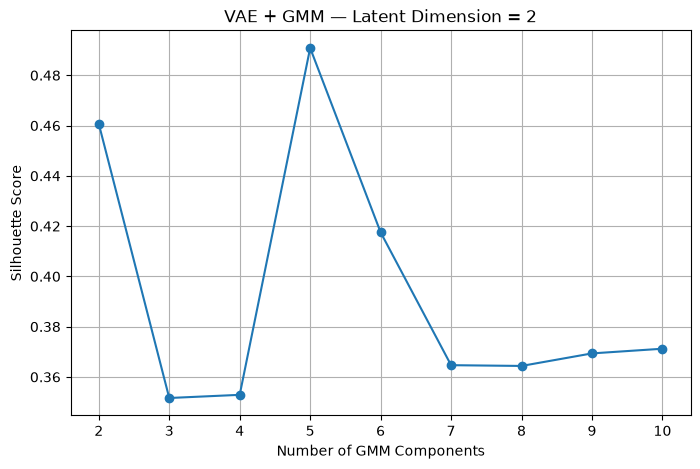

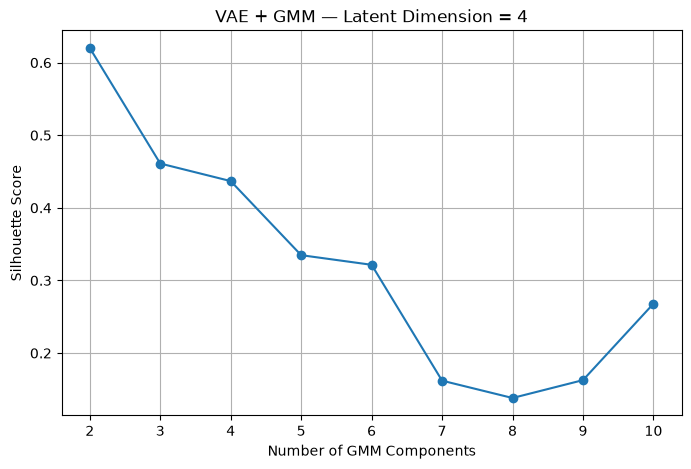

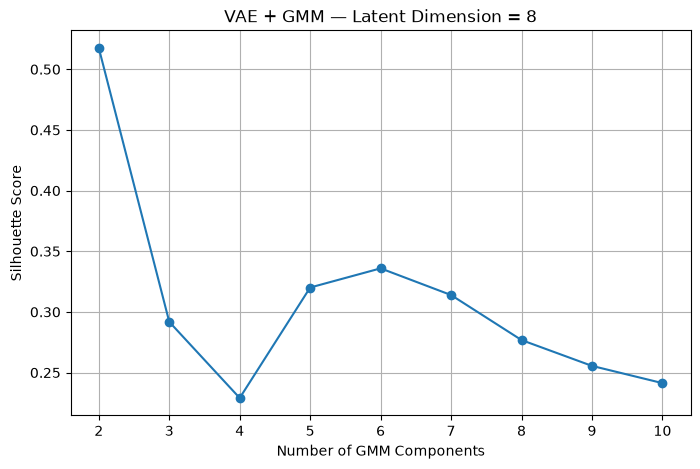

In [66]:
import matplotlib.pyplot as plt

for latent_dim in latent_dimensions:
    
    subset = vae_tuning_results[
        vae_tuning_results[
            "Latent Dimension"
        ] == latent_dim
    ].sort_values(
        "GMM Components"
    )
    
    plt.figure(
        figsize=(8, 5)
    )
    
    plt.plot(
        subset[
            "GMM Components"
        ],
        subset[
            "Silhouette"
        ],
        marker="o"
    )
    
    plt.xlabel(
        "Number of GMM Components"
    )
    
    plt.ylabel(
        "Silhouette Score"
    )
    
    plt.title(
        "VAE + GMM — "
        f"Latent Dimension = {latent_dim}"
    )
    
    plt.grid(True)
    
    plt.show()

In [67]:
best_latent_dim = int(
    best_vae[
        "Latent Dimension"
    ]
)

best_components = int(
    best_vae[
        "GMM Components"
    ]
)

print(
    "Best latent dimension:",
    best_latent_dim
)

print(
    "Best GMM components:",
    best_components
)

Best latent dimension: 4
Best GMM components: 2


In [68]:
print("Training final VAE + GMM...")

final_start = time.time()

(
    final_vae,
    final_encoder,
    final_decoder,
    final_latent,
    final_history
) = train_vae(
    X,
    latent_dim=best_latent_dim,
    epochs=20,
    batch_size=256,
    learning_rate=1e-4
)

final_gmm = GaussianMixture(
    n_components=best_components,
    covariance_type="full",
    reg_covar=1e-4,
    random_state=42,
    n_init=5
)

final_labels = final_gmm.fit_predict(final_latent)
final_time = time.time() - final_start

print(
    "Final training time:",
    round(final_time, 2),
    "seconds"
)

Training final VAE + GMM...
Final training time: 49.18 seconds


In [69]:
final_metrics = evaluate_clustering(
    final_latent,
    final_labels,
    metric_sample_size=10000
)

print("=" * 50)
print("FINAL VAE + GMM")
print("=" * 50)

print(
    "Latent Dimension:",
    best_latent_dim
)

print(
    "GMM Components:",
    best_components
)

print(
    "Silhouette:",
    round(
        final_metrics[
            "Silhouette"
        ],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        final_metrics[
            "Davies-Bouldin"
        ],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        final_metrics[
            "Calinski-Harabasz"
        ],
        2
    )
)

print(
    "Training Time:",
    round(
        final_time,
        2
    ),
    "seconds"
)

FINAL VAE + GMM
Latent Dimension: 4
GMM Components: 2
Silhouette: 0.3763
Davies-Bouldin: 2.4996
Calinski-Harabasz: 886.2
Training Time: 49.18 seconds


In [70]:
import pandas as pd
import numpy as np

# ==========================================
# BEST AUTOENCODER + K-MEANS
# ==========================================

best_ae = ae_tuning_results.loc[
    ae_tuning_results["Silhouette"].idxmax()
]


# ==========================================
# BEST DEC
# ==========================================

best_dec = dec_tuning_results.loc[
    dec_tuning_results["Silhouette"].idxmax()
]


# ==========================================
# BEST VAE + GMM
# ==========================================

best_vae = vae_tuning_results.loc[
    vae_tuning_results["Silhouette"].idxmax()
]


print("Best configurations selected.")

Best configurations selected.


In [71]:
dl_comparison = pd.DataFrame({

    "Model": [
        "Autoencoder + K-Means",
        "DEC",
        "VAE + GMM"
    ],

    "Latent Dimension": [
        best_ae["Latent Dimension"],
        best_dec["Latent Dimension"],
        best_vae["Latent Dimension"]
    ],

    "Clusters": [
        best_ae["K"],
        best_dec["K"],
        best_vae["GMM Components"]
    ],

    "Silhouette": [
        best_ae["Silhouette"],
        best_dec["Silhouette"],
        best_vae["Silhouette"]
    ],

    "Davies-Bouldin": [
        best_ae["Davies-Bouldin"],
        best_dec["Davies-Bouldin"],
        best_vae["Davies-Bouldin"]
    ],

    "Calinski-Harabasz": [
        best_ae["Calinski-Harabasz"],
        best_dec["Calinski-Harabasz"],
        best_vae["Calinski-Harabasz"]
    ],

    "Training Time (s)": [
        best_ae["Training Time (s)"],
        best_dec["Training Time (s)"],
        best_vae["Training Time (s)"]
    ]
})

display(
    dl_comparison.round(4)
)

,Model,Latent Dimension,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
0,Autoencoder + K-Means,2,2,0.8695,0.7719,2670.6476,19.9586
1,DEC,2,5,0.9162,0.3971,36413.1180,25.0508
2,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585


In [72]:
dl_comparison["Silhouette Rank"] = (
    dl_comparison["Silhouette"]
    .rank(
        ascending=False,
        method="min"
    )
)

dl_comparison["DB Rank"] = (
    dl_comparison["Davies-Bouldin"]
    .rank(
        ascending=True,
        method="min"
    )
)

dl_comparison["CH Rank"] = (
    dl_comparison["Calinski-Harabasz"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Average metric rank
dl_comparison["Average Rank"] = (
    dl_comparison[
        [
            "Silhouette Rank",
            "DB Rank",
            "CH Rank"
        ]
    ].mean(axis=1)
)

dl_comparison = dl_comparison.sort_values(
    "Average Rank"
).reset_index(drop=True)

display(
    dl_comparison.round(4)
)

,Model,Latent Dimension,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s),Silhouette Rank,DB Rank,CH Rank,Average Rank
0,DEC,2,5,0.9162,0.3971,36413.1180,25.0508,1.0,1.0,1.0,1.0000
1,Autoencoder + K-Means,2,2,0.8695,0.7719,2670.6476,19.9586,2.0,2.0,3.0,2.3333
2,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585,3.0,3.0,2.0,2.6667


In [73]:
dl_comparison["Final Rank"] = (
    dl_comparison["Average Rank"]
    .rank(
        ascending=True,
        method="min"
    )
)

display(
    dl_comparison.round(4)
)

,Model,Latent Dimension,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s),Silhouette Rank,DB Rank,CH Rank,Average Rank,Final Rank
0,DEC,2,5,0.9162,0.3971,36413.1180,25.0508,1.0,1.0,1.0,1.0000,1.0
1,Autoencoder + K-Means,2,2,0.8695,0.7719,2670.6476,19.9586,2.0,2.0,3.0,2.3333,2.0
2,VAE + GMM,4,2,0.6202,0.8788,8032.6762,20.6585,3.0,3.0,2.0,2.6667,3.0


In [74]:
best_dl_model = dl_comparison.iloc[0]

print("=" * 60)
print("BEST DEEP LEARNING CLUSTERING MODEL")
print("=" * 60)

print(
    "Model:",
    best_dl_model["Model"]
)

print(
    "Silhouette:",
    round(
        best_dl_model["Silhouette"],
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        best_dl_model["Davies-Bouldin"],
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        best_dl_model["Calinski-Harabasz"],
        2
    )
)

print(
    "Average Rank:",
    round(
        best_dl_model["Average Rank"],
        2
    )
)

BEST DEEP LEARNING CLUSTERING MODEL
Model: DEC
Silhouette: 0.9162
Davies-Bouldin: 0.3971
Calinski-Harabasz: 36413.12
Average Rank: 1.0


In [75]:
dl_comparison.to_csv(
    "DL_Models_Final_Comparison.csv",
    index=False
)

print(
    "Saved: DL_Models_Final_Comparison.csv"
)

Saved: DL_Models_Final_Comparison.csv
